In [1]:
# This codes are meant to demonstrate how to use a database of words encoded as vectors (specifically GloVe database).
   

In [ ]:
import gensim.downloader as api
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt


In [2]:
import numpy as np

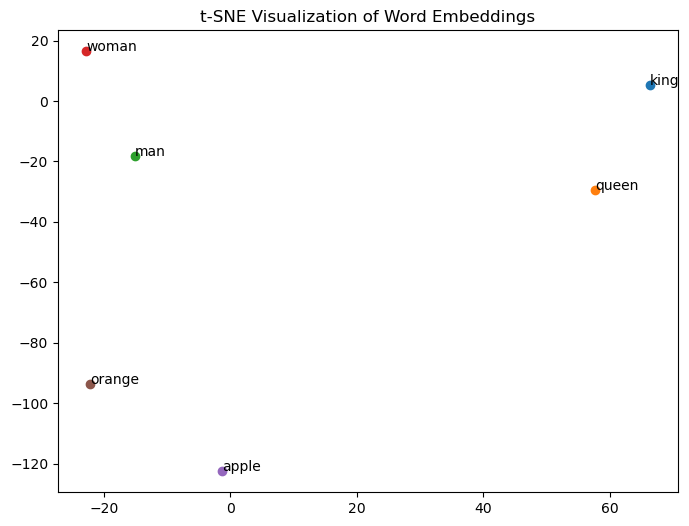

In [3]:
# Load pre-trained model (e.g., GloVe)
# GloVe is  an unsupervised learning algorithm for obtaining vector representations for words.
# This is achieved by mapping words into a meaningful space where the distance between words is related to semantic similarity.
# You can read more here https://en.wikipedia.org/wiki/GloVe
# The output of the glove model is an optimized set of vectors representing different words. These vectors are optimized 
# in such a way that they have similar component is the word meanings are similar.
# GloVe model is trained using log-bilinear regression model so it does not use transformers used in e.g. ChatGPT a
    
model = api.load("glove-wiki-gigaword-100")
words = ['king', 'queen', 'man', 'woman', 'apple', 'orange']
word_vectors = [model[w] for w in words]

# Convert list of word vectors to a NumPy array
word_vectors = np.array([model[w] for w in words])

tsne = TSNE(n_components=2, perplexity=3, random_state=42)
X_tsne = tsne.fit_transform(word_vectors)

plt.figure(figsize=(8,6))
for i, word in enumerate(words):
    plt.scatter(X_tsne[i, 0], X_tsne[i, 1])
    plt.annotate(word, (X_tsne[i, 0], X_tsne[i, 1]))
plt.title("t-SNE Visualization of Word Embeddings")
plt.show()



In [5]:
## uncomment the line below to see the actual vectors
#word_vectors

In [ ]:
# Another example 

Word 'Paris' not found in the model vocabulary.
Word 'London' not found in the model vocabulary.


/Users/kargaltsev/mambaforge/envs/p310/lib/python3.10/site-packages/sklearn/cluster/_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(


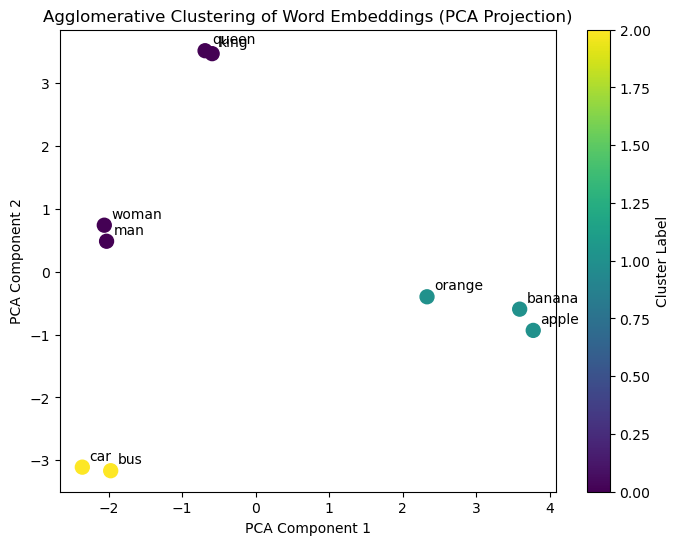

In [2]:
import gensim.downloader as api
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def get_word_embeddings(words, model_name="glove-wiki-gigaword-100"):
    """
    Load a pre-trained model and return embeddings for the provided list of words.
    
    Parameters:
        words (list of str): List of words for which embeddings are desired.
        model_name (str): Name of the pre-trained model.
    
    Returns:
        embeddings_dict (dict): Mapping of words to embedding vectors.
        embeddings_array (np.ndarray): Array of embeddings for words found.
        valid_words (list): List of words that were found in the vocabulary.
    """
    model = api.load(model_name)
    embeddings_dict = {}
    valid_words = []
    
    for word in words:
        if word in model:
            embeddings_dict[word] = model[word]
            valid_words.append(word)
        else:
            print(f"Word '{word}' not found in the model vocabulary.")
    
    embeddings_array = np.array([embeddings_dict[word] for word in valid_words])
    return embeddings_dict, embeddings_array, valid_words

# List of words to embed and cluster
words = ['king', 'queen', 'man', 'woman', 'apple', 'orange', 'Paris', 'London', 'banana', 'car', 'bus']

# Generate embeddings for the words
embeddings_dict, embeddings_array, valid_words = get_word_embeddings(words)

# Compute the cosine similarity matrix and then the distance matrix
similarity_matrix = cosine_similarity(embeddings_array)
distance_matrix = 1 - similarity_matrix

# Perform Agglomerative Clustering using the precomputed distance matrix
# Choose a number of clusters, e.g., 3 clusters.
clustering = AgglomerativeClustering(affinity='precomputed', linkage='average', n_clusters=3)
cluster_labels = clustering.fit_predict(distance_matrix)

# Reduce dimensions of the original embeddings to 2D for visualization using PCA
pca = PCA(n_components=2, random_state=42)
embeddings_2d = pca.fit_transform(embeddings_array)

# Plot the 2D visualization with clusters
plt.figure(figsize=(8, 6))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=cluster_labels, cmap='viridis', s=100)
for i, word in enumerate(valid_words):
    plt.annotate(word, (embeddings_2d[i, 0], embeddings_2d[i, 1]), textcoords="offset points", xytext=(5,5))
plt.title("Agglomerative Clustering of Word Embeddings (PCA Projection)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(scatter, label='Cluster Label')
plt.show()
